# 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, auc, classification_report, confusion_matrix, f1_score, precision_score, precision_recall_curve, recall_score, roc_auc_score

# 2. Load and Explore Data

In [64]:
df = pd.read_csv('StudentPerformanceFactors.csv')
print(f"Loaded dataset: StudentPerformanceFactors.csv")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("Missing values per column:\n", df.isnull().sum())
df = df.dropna()
print(f"After dropping missing values: {df.shape}")

Loaded dataset: StudentPerformanceFactors.csv
Shape: (6607, 20)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
Missing values per column:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Dis

# 3. Prepare Features and Target


In [65]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
X = pd.get_dummies(X, drop_first=True)
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")



Number of features: 27
Number of samples: 6378


# 4. Train-Test Split and Feature Scaling


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")



Training set shape: (5102, 27)
Test set shape: (1276, 27)


# 5. Model Training


In [67]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train_scaled, y_train)
print("K-Nearest Neighbors Regressor model trained.")



K-Nearest Neighbors Regressor model trained.


# Create binary classes from regression values (example threshold: median value)

In [68]:
threshold = np.median(y_test)
y_test_class = (y_test > threshold).astype(int)
y_pred_raw = model.predict(X_test_scaled)
y_pred_norm = (y_pred_raw - min(y_pred_raw)) / (max(y_pred_raw) - min(y_pred_raw))
from sklearn.metrics import precision_recall_curve, auc

# 7. Actual vs Predicted Plot


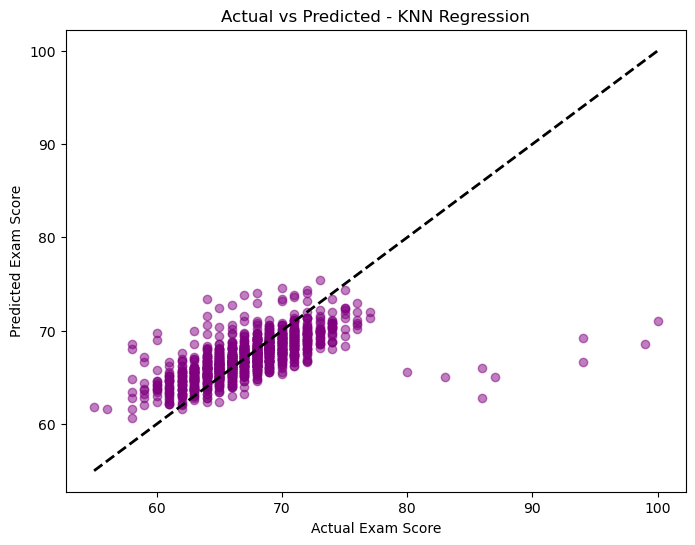

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted - KNN Regression')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()



# 8. Classification Metrics on Continuous Data (Threshold = 60)



# 9. Precision-Recall Curve and PR AUC


PR AUC Score    : 0.8363



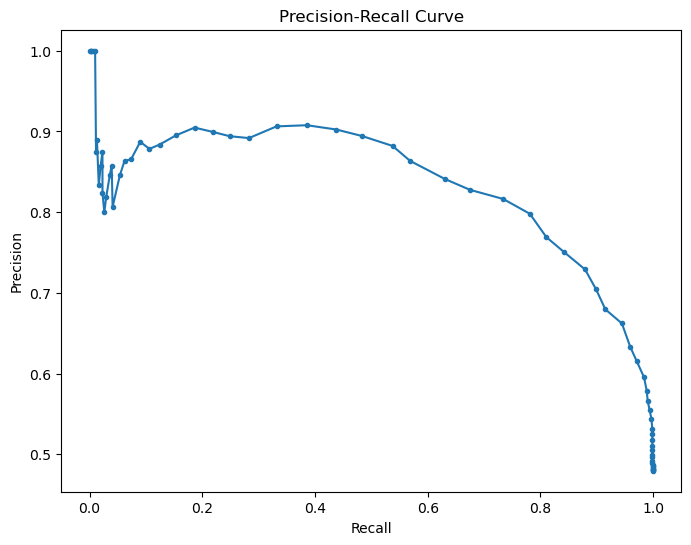

In [70]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test_class, y_pred_norm)
pr_auc = auc(recall_curve, precision_curve)
print(f"PR AUC Score    : {pr_auc:.4f}\n")
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, marker='.')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()



# 10. Sample Data Prediction


In [71]:
print("\n--- SAMPLE PREDICTION ---")
sample_features = X_test.iloc[[0]]
actual_score = y_test.iloc[0]
sample_scaled = scaler.transform(sample_features)
predicted_score = model.predict(sample_scaled)[0]
print(f"Actual Exam Score    : {actual_score}")
print(f"Predicted Exam Score : {predicted_score:.2f}")


--- SAMPLE PREDICTION ---
Actual Exam Score    : 74
Predicted Exam Score : 70.20
